<a href="https://colab.research.google.com/github/amiradif40-cmd/briere-satellite-analysis/blob/main/vegetation_analysis_2025_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Installation des packages geospatial
!pip install pystac-client planetary-computer rasterio numpy matplotlib


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 1.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 3.0 MB/s eta 0:00:00


In [ ]:
import pystac_client
import planetary_computer
import rasterio
from rasterio.windows import from_bounds
from rasterio.warp import transform_bounds
from rasterio.enums import Resampling
import numpy as np
import matplotlib.pyplot as plt
import os

# --- FONCTIONS DE CALCUL DES INDICES SPECTRAUX ---

def calculate_ndvi(red, nir):
    """NDVI - Santé globale de la végétation (Chlorophylle)"""
    red, nir = red.astype(np.float32), nir.astype(np.float32)
    mask = (red == 0) & (nir == 0)
    denom = nir + red
    with np.errstate(divide='ignore', invalid='ignore'):
        index = np.where(denom == 0, np.nan, (nir - red) / denom)
    index[mask] = np.nan
    return index

def calculate_ndwi(green, nir):
    """NDWI - Détection des surfaces d'eau et humidité générale"""
    green, nir = green.astype(np.float32), nir.astype(np.float32)
    mask = (green == 0) & (nir == 0)
    denom = green + nir
    with np.errstate(divide='ignore', invalid='ignore'):
        index = np.where(denom == 0, np.nan, (green - nir) / denom)
    index[mask] = np.nan
    return index

def calculate_evi(blue, red, nir):
    """EVI - Végétation dense (sans saturation atmosphérique/sol)"""
    blue, red, nir = blue.astype(np.float32), red.astype(np.float32), nir.astype(np.float32)
    mask = (red == 0) & (nir == 0)
    denom = nir + 6.0 * red - 7.5 * blue + 1.0
    with np.errstate(divide='ignore', invalid='ignore'):
        index = np.where(denom == 0, np.nan, 2.5 * ((nir - red) / denom))
    index[mask] = np.nan
    return np.clip(index, -1.0, 1.5)

def calculate_savi(red, nir, L=0.5):
    """SAVI - Végétation ajustée pour corriger la réflectance des sols nus"""
    red, nir = red.astype(np.float32), nir.astype(np.float32)
    mask = (red == 0) & (nir == 0)
    denom = nir + red + L
    with np.errstate(divide='ignore', invalid='ignore'):
        index = np.where(denom == 0, np.nan, ((nir - red) / denom) * (1.0 + L))
    index[mask] = np.nan
    return index

def calculate_ndmi(nir, swir1):
    """NDMI - Teneur en eau interne des tissus végétaux (Stress hydrique foliaire)"""
    nir, swir1 = nir.astype(np.float32), swir1.astype(np.float32)
    mask = (nir == 0) & (swir1 == 0)
    denom = nir + swir1
    with np.errstate(divide='ignore', invalid='ignore'):
        index = np.where(denom == 0, np.nan, (nir - swir1) / denom)
    index[mask] = np.nan
    return index

def calculate_nbr(nir, swir2):
    """NBR - Matière végétale sèche/morte et niveau de dessèchement"""
    nir, swir2 = nir.astype(np.float32), swir2.astype(np.float32)
    mask = (nir == 0) & (swir2 == 0)
    denom = nir + swir2
    with np.errstate(divide='ignore', invalid='ignore'):
        index = np.where(denom == 0, np.nan, (nir - swir2) / denom)
    index[mask] = np.nan
    return index

# --- TÉLÉCHARGEMENT SATELLITE AVEC RE-SAMPLING DYNAMIQUE ---

def fetch_sentinel_data(bbox, date_range, max_cloud=15):
    """Télécharge et rééchantillonne les bandes Sentinel-2 sur une grille commune 10m."""
    print(f" Recherche d'images pour {date_range}...")
    catalog = pystac_client.Client.open(
        "https://planetarycomputer.microsoft.com/api/stac/v1",
        modifier=planetary_computer.sign_inplace,
    )
    search = catalog.search(
        collections=["sentinel-2-l2a"],
        bbox=bbox,
        datetime=date_range,
        query={"eo:cloud_cover": {"lt": max_cloud}},
    )
    items = list(search.items())
    if not items:
        raise ValueError(f" Aucune image trouvée pour {date_range}")

    r137_items = [item for item in items if item.properties.get("sat:relative_orbit") == 137]
    best_item = min(r137_items if r137_items else items, key=lambda item: item.properties["eo:cloud_cover"])

    image_date = best_item.datetime.strftime('%Y-%m-%d')
    print(f" Image retenue : {best_item.id} du {image_date} ({best_item.properties['eo:cloud_cover']:.2f}% nuages)")

    bands = {}

    # 1. On lit d'abord B04 pour obtenir la forme de référence 10m (target_shape)
    with rasterio.open(best_item.assets['B04'].href) as src:
        bbox_crs = transform_bounds('EPSG:4326', src.crs, *bbox)
        window = from_bounds(*bbox_crs, transform=src.transform)
        target_data = src.read(1, window=window)
        target_shape = target_data.shape  # Hauteur, Largeur à 10m
        bands['B04'] = target_data.astype(np.float32)

    # 2. On lit les autres bandes en les forçant à s'adapter à target_shape (Resampling.bilinear pour B11/B12)
    other_bands = ['B02', 'B03', 'B08', 'B11', 'B12']
    for band_name in other_bands:
        href = best_item.assets[band_name].href
        with rasterio.open(href) as src:
            bbox_crs = transform_bounds('EPSG:4326', src.crs, *bbox)
            window = from_bounds(*bbox_crs, transform=src.transform)
            bands[band_name] = src.read(
                1,
                window=window,
                out_shape=target_shape,
                resampling=Resampling.bilinear
            ).astype(np.float32)

    return bands, image_date

# --- AFFICHAGE GRAPHIQUE ---

def plot_index_comparison(data_2025, data_2026, date_2025, date_2026, title_prefix, cmap, vmin, vmax, diff_cmap="RdBu", diff_vmin=-0.3, diff_vmax=0.3, output_path=None):
    """Génère la comparaison visuelle 2025 vs 2026 + la variation Delta."""
    diff = data_2026 - data_2025
    fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharex=True, sharey=True)

    im1 = axes[0].imshow(data_2025, cmap=cmap, vmin=vmin, vmax=vmax)
    axes[0].set_title(f"{title_prefix} St-Malo-de-Guersac\n{date_2025}", fontsize=12, fontweight='bold')
    plt.colorbar(im1, ax=axes[0], shrink=0.7)

    im2 = axes[1].imshow(data_2026, cmap=cmap, vmin=vmin, vmax=vmax)
    axes[1].set_title(f"{title_prefix} St-Malo-de-Guersac\n{date_2026}", fontsize=12, fontweight='bold')
    plt.colorbar(im2, ax=axes[1], shrink=0.7)

    im3 = axes[2].imshow(diff, cmap=diff_cmap, vmin=diff_vmin, vmax=diff_vmax)
    axes[2].set_title(f"Variation Delta-{title_prefix}\n(Août 2026 vs Août 2025)", fontsize=12, fontweight='bold')
    plt.colorbar(im3, ax=axes[2], shrink=0.7)

    for ax in axes:
        ax.axis('off')

    plt.suptitle(f"Analyse Spatiale Multi-Indice : {title_prefix} - Marais de Brière (44)", fontsize=15, fontweight='bold')
    plt.tight_layout()

    if output_path:
        os.makedirs(os.path.dirname(output_path), exist_ok=True)
        plt.savefig(output_path, dpi=300, bbox_inches='tight')
        print(f" Graphique enregistré : {output_path}")

    plt.show()
    plt.close()

print(" Fonctions avec rééchantillonnage 10m prêtes !")

 Fonctions avec rééchantillonnage 10m prêtes !


 Recherche d'images pour 2025-08-01/2025-08-20...
 Image retenue : S2A_MSIL2A_20250810T110701_R137_T30TWT_20250810T151608 du 2025-08-10 (0.00% nuages)
 Recherche d'images pour 2026-08-01/2026-08-20...
 Image retenue : S2C_MSIL2A_20260813T110621_R137_T30TWT_20260813T144414 du 2026-08-13 (0.01% nuages)

--- GÉNÉRATION DE LA CARTE : NDVI (Santé Végétale) ---
 Graphique enregistré : figures/briere_ndvi_comparison.png


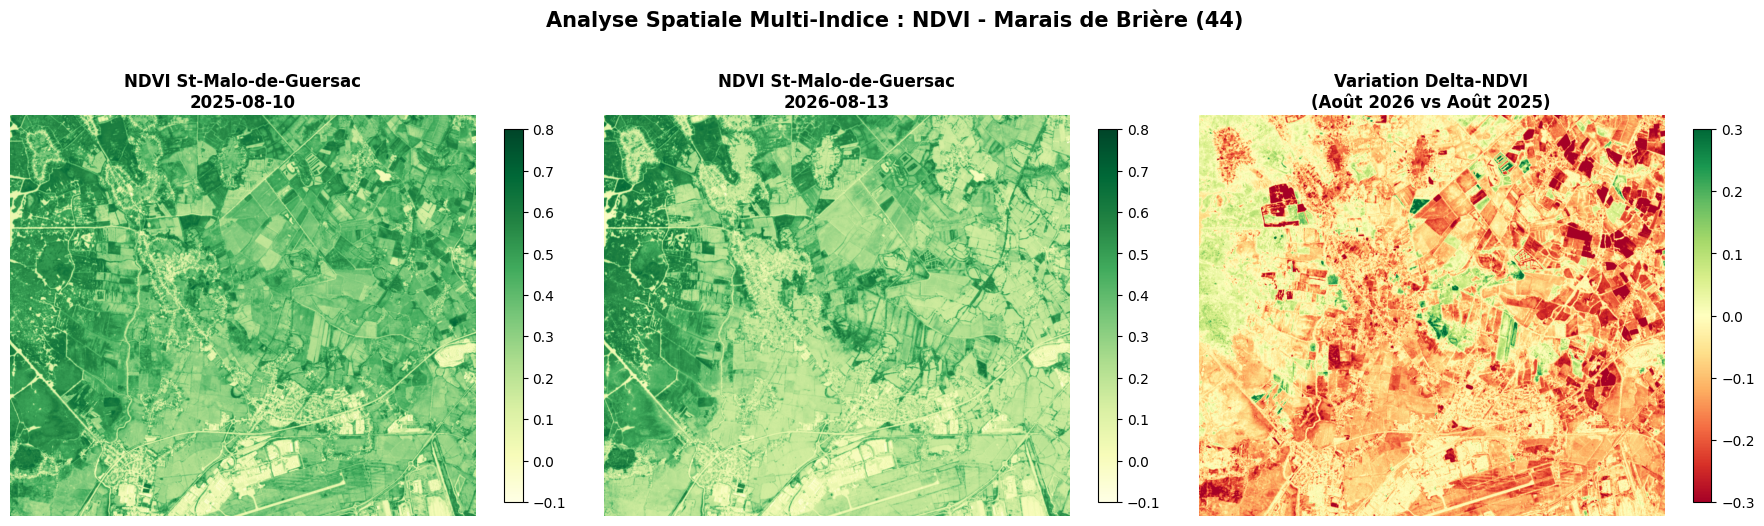


--- GÉNÉRATION DE LA CARTE : NDWI (Surfaces d'Eau & Sol Nu) ---
 Graphique enregistré : figures/briere_ndwi_comparison.png


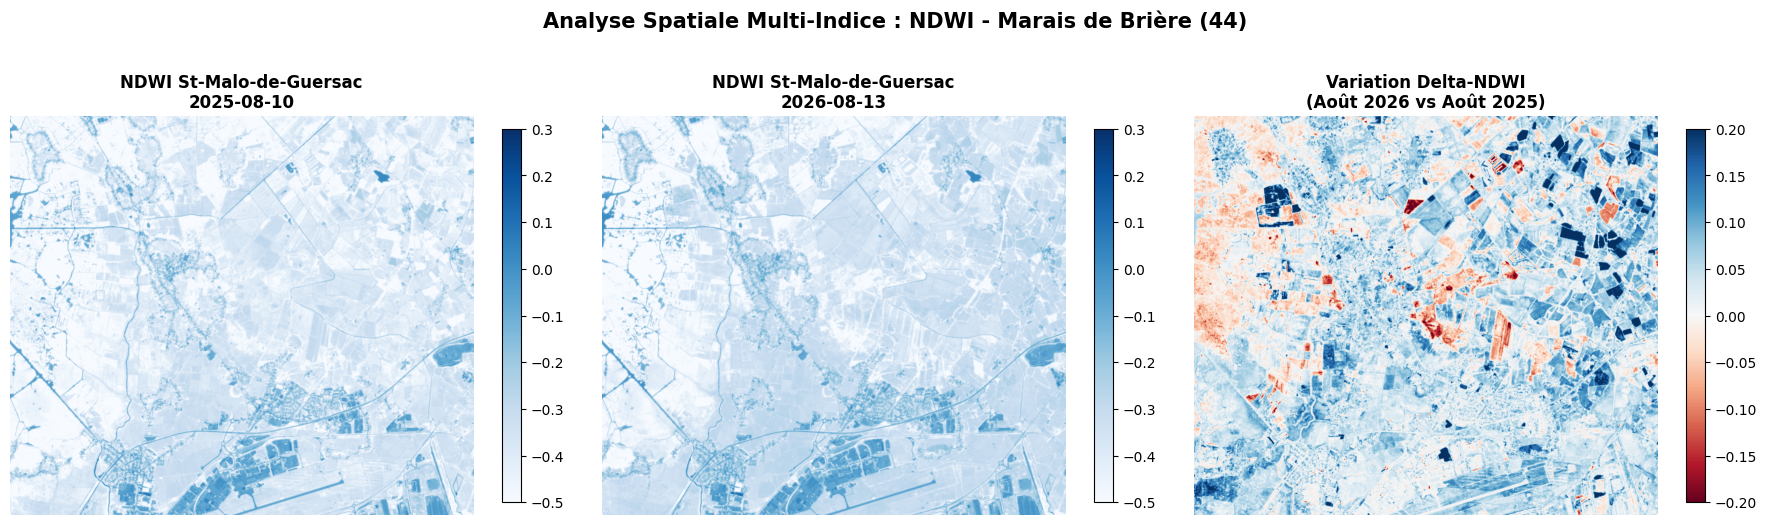


--- GÉNÉRATION DE LA CARTE : EVI (Végétation Dense (Canopée)) ---
 Graphique enregistré : figures/briere_evi_comparison.png


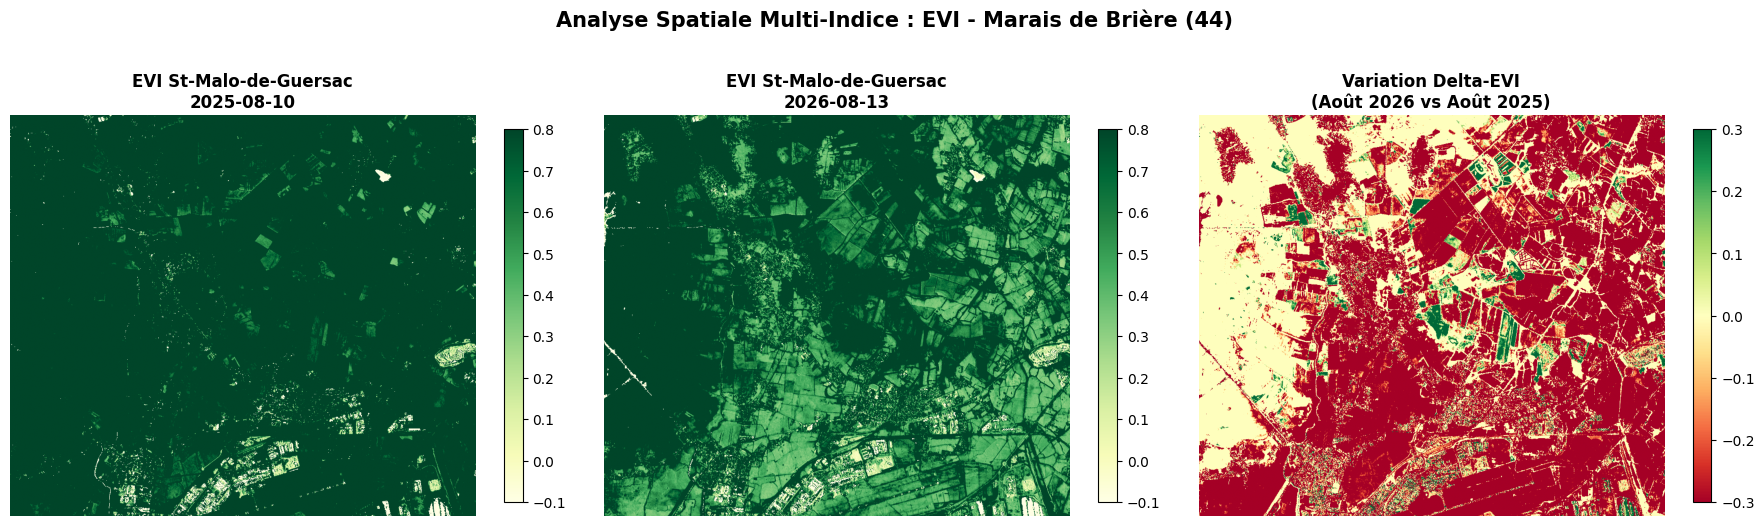


--- GÉNÉRATION DE LA CARTE : SAVI (Végétation (Ajustée Sol Nu)) ---
 Graphique enregistré : figures/briere_savi_comparison.png


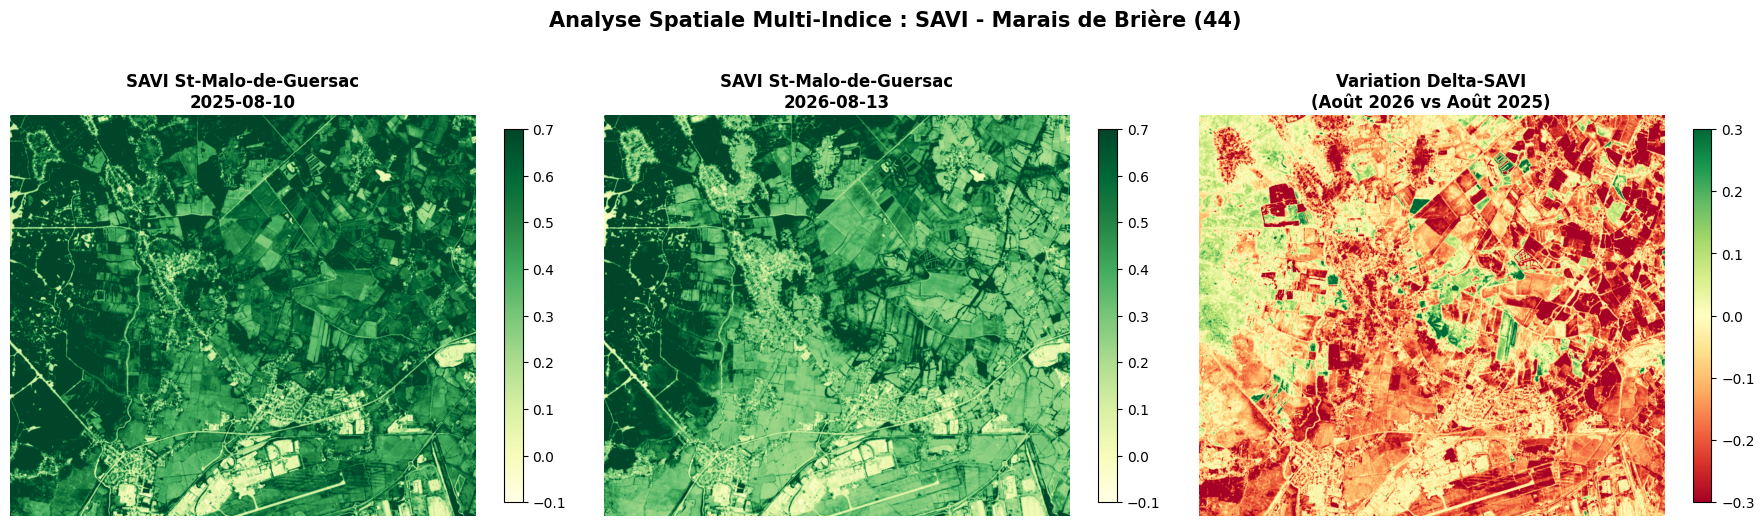


--- GÉNÉRATION DE LA CARTE : NDMI (Stress Hydrique Foliaire) ---
 Graphique enregistré : figures/briere_ndmi_comparison.png


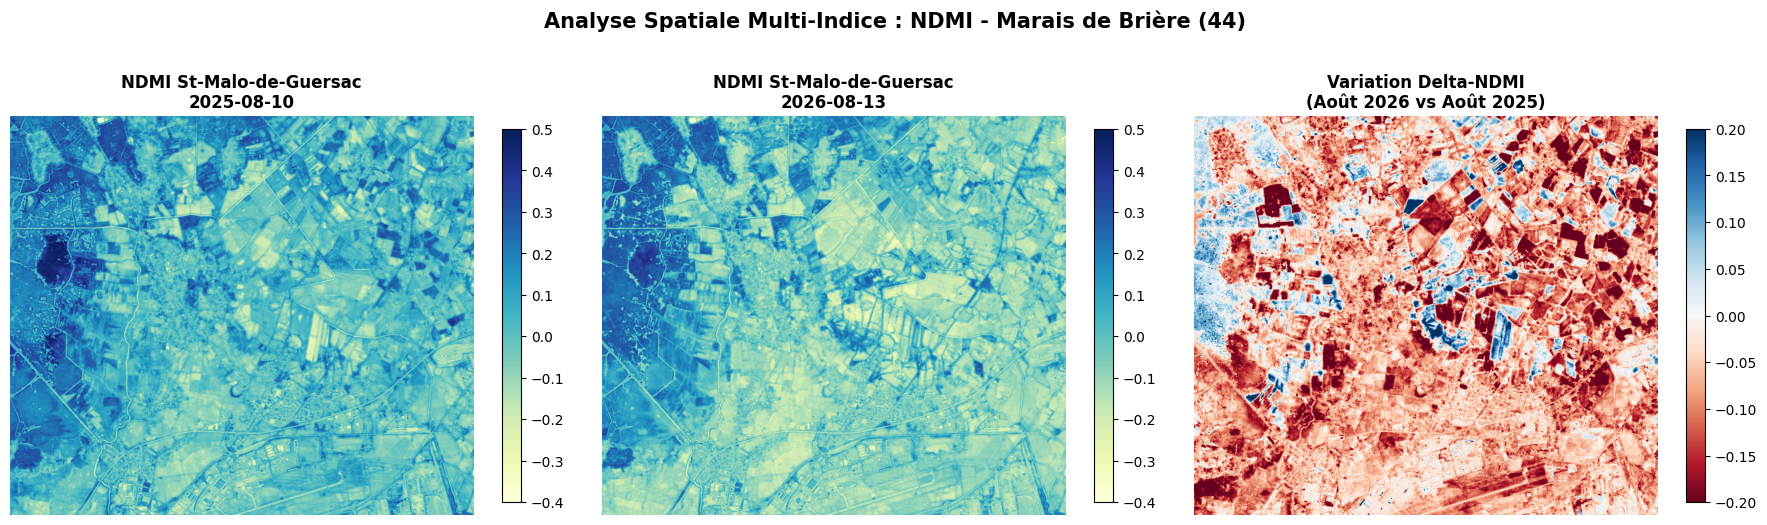


--- GÉNÉRATION DE LA CARTE : NBR (Dessèchement / Matière Sèche) ---
 Graphique enregistré : figures/briere_nbr_comparison.png


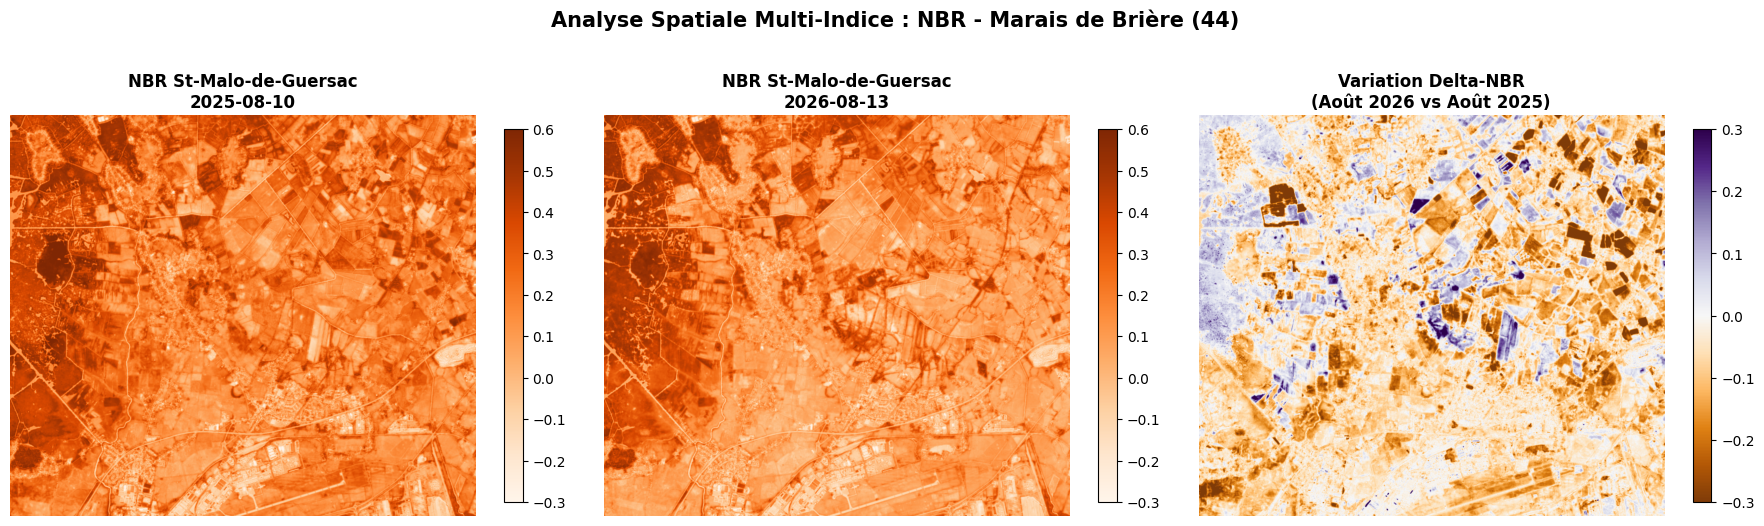


 TABLEAU DE SYNTHÈSE MULTI-INDICES — BRIÈRE / ST-MALO-DE-GUERSAC
 Comparaison du 2025-08-10 vs 2026-08-13
Indice   | Description                  | 2025    | 2026    | Delta    | Var (%) 
--------------------------------------------------------------------------------
NDVI     | Santé Végétale               | +0.379  | +0.299  | -0.079   | -20.97%
NDWI     | Surfaces d'Eau & Sol Nu      | -0.381  | -0.345  | +0.036   |  +9.40%
EVI      | Végétation Dense (Canopée)   | +1.302  | +0.946  | -0.356   | -27.36%
SAVI     | Végétation (Ajustée Sol Nu)  | +0.568  | +0.449  | -0.119   | -20.97%
NDMI     | Stress Hydrique Foliaire     | +0.053  | -0.016  | -0.069   | -131.14%
NBR      | Dessèchement / Matière Sèche | +0.218  | +0.160  | -0.058   | -26.43%


In [ ]:
























# 1. Emprise spatiale
BBOX = [-2.22, 47.31, -2.10, 47.38]

# 2. Périodes de comparaison
SUMMER_2025 = "2025-08-01/2025-08-20"
SUMMER_2026 = "2026-08-01/2026-08-20"

# 3. Récupération des bandes multispectrales
data_2025, date_2025 = fetch_sentinel_data(BBOX, SUMMER_2025, max_cloud=15)
data_2026, date_2026 = fetch_sentinel_data(BBOX, SUMMER_2026, max_cloud=15)

# 4. Calcul de l'ensemble des indices pour 2025 et 2026
indices_config = {
    "NDVI": {
        "calc": lambda d: calculate_ndvi(d['B04'], d['B08']),
        "cmap": "YlGn", "vmin": -0.1, "vmax": 0.8, "diff_cmap": "RdYlGn", "diff_vmin": -0.3, "diff_vmax": 0.3,
        "desc": "Santé Végétale"
    },
    "NDWI": {
        "calc": lambda d: calculate_ndwi(d['B03'], d['B08']),
        "cmap": "Blues", "vmin": -0.5, "vmax": 0.3, "diff_cmap": "RdBu", "diff_vmin": -0.2, "diff_vmax": 0.2,
        "desc": "Surfaces d'Eau & Sol Nu"
    },
    "EVI": {
        "calc": lambda d: calculate_evi(d['B02'], d['B04'], d['B08']),
        "cmap": "YlGn", "vmin": -0.1, "vmax": 0.8, "diff_cmap": "RdYlGn", "diff_vmin": -0.3, "diff_vmax": 0.3,
        "desc": "Végétation Dense (Canopée)"
    },
    "SAVI": {
        "calc": lambda d: calculate_savi(d['B04'], d['B08']),
        "cmap": "YlGn", "vmin": -0.1, "vmax": 0.7, "diff_cmap": "RdYlGn", "diff_vmin": -0.3, "diff_vmax": 0.3,
        "desc": "Végétation (Ajustée Sol Nu)"
    },
    "NDMI": {
        "calc": lambda d: calculate_ndmi(d['B08'], d['B11']),
        "cmap": "YlGnBu", "vmin": -0.4, "vmax": 0.5, "diff_cmap": "RdBu", "diff_vmin": -0.2, "diff_vmax": 0.2,
        "desc": "Stress Hydrique Foliaire"
    },
    "NBR": {
        "calc": lambda d: calculate_nbr(d['B08'], d['B12']),
        "cmap": "Oranges", "vmin": -0.3, "vmax": 0.6, "diff_cmap": "PuOr", "diff_vmin": -0.3, "diff_vmax": 0.3,
        "desc": "Dessèchement / Matière Sèche"
    }
}

results = {}

# 5. Boucle de génération et sauvegarde
for name, cfg in indices_config.items():
    print(f"\n--- GÉNÉRATION DE LA CARTE : {name} ({cfg['desc']}) ---")
    val_2025 = cfg["calc"](data_2025)
    val_2026 = cfg["calc"](data_2026)

    results[name] = {
        "m2025": np.nanmean(val_2025),
        "m2026": np.nanmean(val_2026),
        "desc": cfg["desc"]
    }

    plot_index_comparison(
        val_2025, val_2026, date_2025, date_2026,
        title_prefix=name, cmap=cfg["cmap"], vmin=cfg["vmin"], vmax=cfg["vmax"],
        diff_cmap=cfg["diff_cmap"], diff_vmin=cfg["diff_vmin"], diff_vmax=cfg["diff_vmax"],
        output_path=f"figures/briere_{name.lower()}_comparison.png"
    )

# 6. Affichage du tableau synthétique global
print("\n" + "=" * 80)
print(f" TABLEAU DE SYNTHÈSE MULTI-INDICES — BRIÈRE / ST-MALO-DE-GUERSAC")
print(f" Comparaison du {date_2025} vs {date_2026}")
print("=" * 80)
print(f"{'Indice':<8} | {'Description':<28} | {'2025':<7} | {'2026':<7} | {'Delta':<8} | {'Var (%)':<8}")
print("-" * 80)

for name, res in results.items():
    m25 = res["m2025"]
    m26 = res["m2026"]
    diff = m26 - m25
    pct = (diff / abs(m25)) * 100 if m25 != 0 else 0.0
    print(f"{name:<8} | {res['desc']:<28} | {m25:+.3f}  | {m26:+.3f}  | {diff:+.3f}   | {pct:+6.2f}%")

print("=" * 80)

# Guide de lecture des cartes & bilan de l'analyse

Voici comment lire les 6 cartes satellite et comprendre ce qu'elles révèlent sur le Marais de Brière entre août 2025 et août 2026.

---

### 🌿 1. NDVI — Santé de la végétation
* **La formule :** $\text{NDVI} = \frac{\text{B08} - \text{B04}}{\text{B08} + \text{B04}}$
* **Les couleurs :** Vert foncé = Végétation très dense | Vert clair/Jaune = Végétation rase ou fauchée | Beige = Sol nu ou ville.
* **Sur la carte Delta :** **Rouge** = Perte de vert | **Vert** = Gain de vert.
* **En clair :** C'est le niveau de chlorophylle. La baisse de **-21%** se voit surtout sur les parcelles agricoles à l'Est (grands rectangles rouges), signe de moissons ou de fauches effectuées plus tôt qu'en 2025.

---

### 💧 2. NDWI — Eau libre & sol mis à nu
* **La formule :** $\text{NDWI} = \frac{\text{B03} - \text{B08}}{\text{B03} + \text{B08}}$
* **Les couleurs :** Bleu foncé = Eau (canaux, étangs) | Blanc/Bleu très clair = Terre ferme.
* **Sur la carte Delta :** **Bleu** = Augmentation du signal "eau / sol nu" | **Rouge** = Végétation dense / assèchement.
* **En clair :** Cet indice repère les zones humides. La hausse de **+9.4%** ne veut pas dire qu'il y a plus d'eau, mais que la coupe des cultures laisse le sol nu, ce qui modifie la signature optique vers le bleu.

---

### 🌳 3. EVI — Densité du feuillage (Canopée)
* **La formule :** $\text{EVI} = 2.5 \times \frac{\text{B08} - \text{B04}}{\text{B08} + 6\text{B04} - 7.5\text{B02} + 1}$
* **Les couleurs :** Vert foncé = Massifs forestiers et feuillage épais | Jaune = Végétation rase ou sol nu.
* **En clair :** Une version haute précision du NDVI qui ne sature pas dans les zones très denses (arbres, buissons). C'est l'indice qui chute le plus (**-27.4%**), preuve d'une baisse globale du volume de feuillage sur toute la zone.

---

### 🌾 4. SAVI — Végétation corrigée de l'effet du sol
* **La formule :** $\text{SAVI} = \frac{\text{B08} - \text{B04}}{\text{B08} + \text{B04} + 0.5} \times 1.5$
* **Les couleurs :** Idem NDVI, mais en supprimant l'effet visuel de la terre sous les plantes rases.
* **En clair :** Il donne les mêmes résultats que le NDVI (baisse de **-21%**). Cela confirme scientifiquement que la perte de biomasse est bien réelle et n'est pas un illusion d'optique due à la couleur du sol.

---

### 🌵 5. NDMI — Eau dans les feuilles (Stress hydrique)
* **La formule :** $\text{NDMI} = \frac{\text{B08} - \text{B11}}{\text{B08} + \text{B11}}$
* **Les couleurs :** Bleu = Feuilles bien hydratées | Jaune/Blanc = Feuilles flétries / déshydratées.
* **Sur la carte Delta :** **Rouge foncé** = Perte d'eau dans les tissus de la plante.
* **En clair :** Il mesure l'eau *à l'intérieur* de la plante. La chute brutale (**-131%**, l'indice devenant négatif) montre un stress hydrique important : la végétation encore en place souffre d'un net manque d'eau.

---

### 🍂 6. NBR — Dessèchement & Paille
* **La formule :** $\text{NBR} = \frac{\text{B08} - \text{B12}}{\text{B08} + \text{B12}}$
* **Les couleurs :** Marron foncé = Végétation fraîche et humide | Orange/Blanc = Matière sèche, paille, chaume.
* **Sur la carte Delta :** **Marron** = Dessèchement de la végétation | **Violet** = Biomasse fraîche.
* **En clair :** Cet indice est très sensible à la paille et aux herbes mortes. La baisse de **-26.4%** confirme la présence de grandes étendues de paille et de sol très sec sur les parcelles fauchées.

---

##  Le bilan en résumé

En croisant l'ensemble de ces indices entre août 2025 et août 2026 :

1. **L'action humaine (Fauches & Moissons) :** Les formes géométriques parfaites sur les cartes (en rouge sur NDVI/EVI et en marron sur NBR) montrent des coupes agricoles plus précoces en 2026.
2. **Le facteur météo (Sécheresse foliaire) :** La chute libre du NDMI ($-131\%$) montre que même la végétation résiduelle non fauchée subit un manque d'eau marquant et des feuilles flétries.

Les données satellites ne mentent pas. La chute drastique du NDMI (-131%) et le flétrissement précoce de la canopée illustrent parfaitement les effets des anomalies thermiques et du déficit pluviométrique estival. Face à la répétition de ces épisodes de sécheresse, la végétation perd sa capacité de résilience, ce qui modifie non seulement les cycles agricoles (fauches de plus en plus précoces), mais fragilise aussi des zones humides clés comme le Marais de Brière.
